# Homework 5 - Data visualisation with Python

**Course:** IFI6218.DT - Technologies of Digital Humanities  
**Semester:** Autumn 2026  
**Student:** Kristjan Peedisson  

This notebook analyses a small self-created dataset of 30 plausible Estonian folk-song collection records. The same dataset was used in the previous spreadsheet assignment. It is practice data rather than an archival source.

## 1. Import the dataset

The CSV file is stored in the `notebook/Homework` folder. The notebook reads it using a relative path so the repository structure can be preserved on GitHub.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

csv_path = Path("../Homework/estonian_folk_songs.csv")
data = pd.read_csv(csv_path)

data.head()

,Record ID,Title,Region,Year collected,Collector,Category,Number of verses,Performer age,Language variety
0,F001,Kiigelaul jaaniõhtul,Harjumaa,1884,Mari Kask,Seasonal song,18,46,North Estonian
1,F002,Merele mineku laul,Saaremaa,1886,Juhan Saar,Work song,24,68,Island dialect
2,F003,Pika tee ballaad,Võrumaa,1887,Liisa Tamm,Ballad,16,53,Võro
3,F004,Pruudi saatmise laul,Setomaa,1888,Peeter Lepp,Wedding song,20,61,Seto
4,F005,Hällilaul väikesele õele,Tartumaa,1889,Anna Oja,Lullaby,22,35,Tartu dialect


In [2]:
print(f"Rows: {len(data)}")
print(f"Columns: {len(data.columns)}")
print("Missing values:")
print(data.isna().sum())

Rows: 30
Columns: 9
Missing values:
Record ID           0
Title               0
Region              0
Year collected      0
Collector           0
Category            0
Number of verses    0
Performer age       0
Language variety    0
dtype: int64


The dataset contains 30 records and nine variables. There are no missing values, so the data can be used directly for the visualisations.

## 2. Example of organising the data in Python

The following code selects wedding songs and sorts them by collection year. This is similar to the subset created with the QUERY function in the previous assignment.

In [3]:
wedding_songs = (
    data.loc[data["Category"] == "Wedding song",
             ["Record ID", "Title", "Region", "Year collected", "Number of verses"]]
        .sort_values("Year collected")
)

wedding_songs

,Record ID,Title,Region,Year collected,Number of verses
3,F004,Pruudi saatmise laul,Setomaa,1888,20
7,F008,Pulmalaul saarelt,Saaremaa,1894,28
10,F011,Peigmehe vastuvõtu laul,Setomaa,1898,18
15,F016,Mõrsja itk,Võrumaa,1907,15
18,F019,Pulmalaul kaasitajatele,Tartumaa,1913,17
22,F023,Pruudi lahkumise laul,Võrumaa,1921,12
26,F027,Pulmalaul värava ees,Pärnumaa,1929,13
29,F030,Noorpaari õnnistuslaul,Võrumaa,1938,8


The filtered table contains eight wedding songs collected between 1888 and 1938. This shows that the category appears throughout most of the time period represented in the dataset.

## 3. Chart 1 - Number of records by region

A bar chart is appropriate because the regions are separate categories and the goal is to compare their record counts.

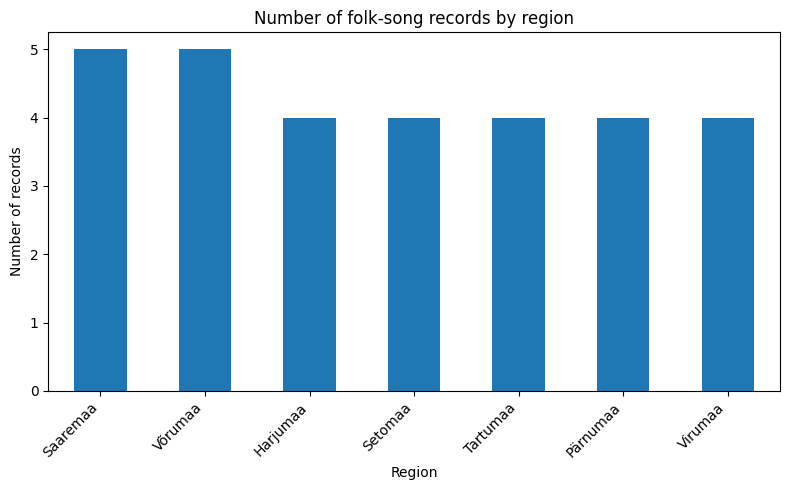

Region
Saaremaa    5
Võrumaa     5
Harjumaa    4
Setomaa     4
Tartumaa    4
Pärnumaa    4
Virumaa     4
Name: count, dtype: int64

In [4]:
region_counts = data["Region"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_counts.plot(kind="bar")
plt.title("Number of folk-song records by region")
plt.xlabel("Region")
plt.ylabel("Number of records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

region_counts

### Reflection

Saaremaa and Võrumaa have the highest number of records, with five each. The remaining regions have four records each, so the sample is fairly balanced and no single region dominates the dataset. This makes regional comparisons possible, although the differences are too small to support broad conclusions about Estonian folk-song traditions.

## 4. Chart 2 - Average number of verses by decade

A line chart is suitable because the decades form an ordered time sequence and the chart shows how average song length changes over time.

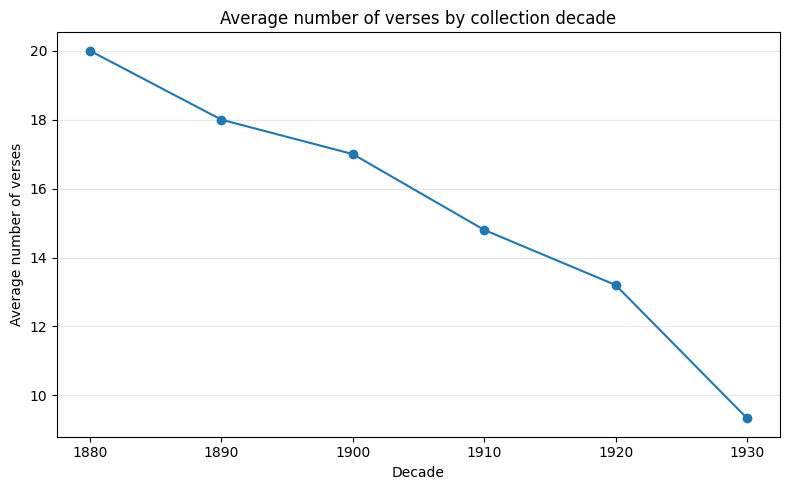

Decade
1880    20.0
1890    18.0
1900    17.0
1910    14.8
1920    13.2
1930     9.3
Name: Number of verses, dtype: float64

In [5]:
data["Decade"] = (data["Year collected"] // 10) * 10
average_verses_by_decade = data.groupby("Decade")["Number of verses"].mean()

plt.figure(figsize=(8, 5))
plt.plot(average_verses_by_decade.index,
         average_verses_by_decade.values,
         marker="o")
plt.title("Average number of verses by collection decade")
plt.xlabel("Decade")
plt.ylabel("Average number of verses")
plt.xticks(average_verses_by_decade.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

average_verses_by_decade.round(1)

### Reflection

The average number of verses decreases steadily from 20.0 in the 1880s to about 9.3 in the 1930s. Within this practice dataset, later records therefore tend to be shorter. One possible interpretation is that collectors recorded shorter versions over time, but the pattern could also be caused by the way the sample was constructed, so it should not be treated as a historical fact.

## 5. Chart 3 - Performer age and number of verses

A scatter plot is appropriate because both performer age and number of verses are numeric variables. It helps show whether longer songs are associated with older or younger performers.

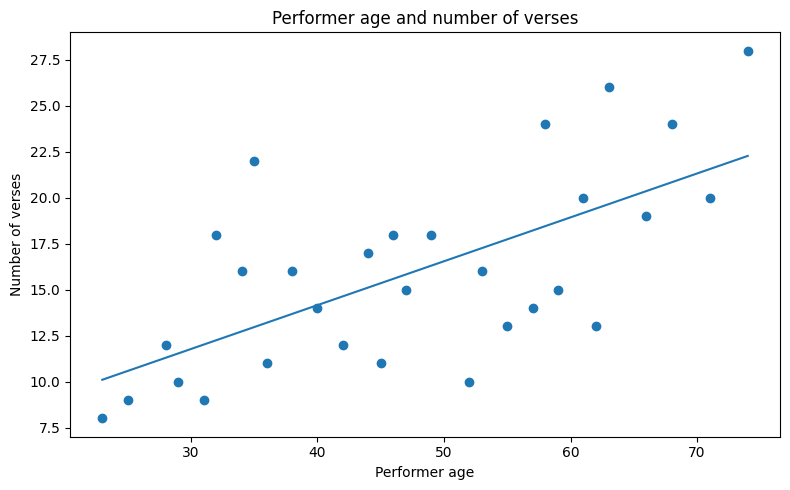

Pearson correlation: 0.66


In [6]:
correlation = data["Performer age"].corr(data["Number of verses"])

x = data["Performer age"]
y = data["Number of verses"]
trend = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend)

plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.plot(x.sort_values(), trend_line(x.sort_values()))
plt.title("Performer age and number of verses")
plt.xlabel("Performer age")
plt.ylabel("Number of verses")
plt.tight_layout()
plt.show()

print(f"Pearson correlation: {correlation:.2f}")

### Reflection

The scatter plot shows a moderate positive relationship, with a Pearson correlation of about 0.66. In this sample, older performers generally have songs with more verses, although the points do not form a perfect line. This could suggest that older performers remembered longer versions, but a larger real dataset would be needed to test that idea properly.

## 6. Conclusion

The visualisations show that the regional distribution is balanced, average song length falls across the collection decades, and performer age has a moderate positive relationship with song length. Because the dataset is small and self-created, these results demonstrate Python data-analysis methods rather than making claims about the full Estonian folk-song tradition.